# E-Commerce Sales & Customer Analytics

## 04 — Customer Analytics

This notebook analyzes customer purchasing behavior using the cleaned transaction dataset.

### Objectives

- Calculate customer-level revenue
- Measure customer purchase frequency
- Identify high-value customers
- Analyze customer geographic distribution
- Calculate Recency, Frequency, and Monetary (RFM) metrics
- Segment customers based on purchasing behavior
- Identify customers with high business value
- Generate insights that can support customer retention and marketing decisions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Cleaned Transaction Data

The customer analysis will be performed using the validated dataset produced in the previous notebook.

The dataset contains valid sales transactions after removing cancelled transactions, zero-price transactions, and identified non-merchandise transactions.

In [2]:
cleaned_path = "../data/cleaned_sales.csv"

df_sales = pd.read_csv(
    cleaned_path,
    parse_dates=["invoicedate"]
)

print("Dataset loaded successfully.")
print("Rows:", f"{len(df_sales):,}")
print("Columns:", len(df_sales.columns))

Dataset loaded successfully.
Rows: 993,401
Columns: 10


## 2. Customer Analysis Data Validation

Before calculating customer metrics, we verify that the cleaned dataset has the required fields and that customer identifiers are available where possible.

In [3]:
print("Columns:")
print(df_sales.columns.tolist())

print("\nMissing Customer IDs:")
print(f"{df_sales['customer_id'].isna().sum():,}")

print("\nDate range:")
print(df_sales["invoicedate"].min())
print(df_sales["invoicedate"].max())

Columns:
['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country', 'is_cancelled', 'revenue']

Missing Customer IDs:
224,593

Date range:
2009-12-01 07:45:00
2011-12-09 12:50:00


## 3. Prepare Customer-Level Dataset

Customer-level analysis requires a valid Customer ID for each transaction.

Transactions without a Customer ID cannot be reliably attributed to an individual customer, so they will be excluded from customer-level metrics while remaining available in the transaction-level dataset.

This allows us to preserve the original sales data while ensuring that customer metrics are calculated accurately.

In [4]:
# Keep only transactions with a known Customer ID
customer_df = df_sales.loc[
    df_sales["customer_id"].notna()
].copy()

# Convert Customer ID to integer
customer_df["customer_id"] = customer_df["customer_id"].astype(int)

print("Customer-level transactions:", f"{len(customer_df):,}")
print("Unique customers:", f"{customer_df['customer_id'].nunique():,}")
print("Missing Customer IDs:", customer_df["customer_id"].isna().sum())

Customer-level transactions: 768,808
Unique customers: 5,851
Missing Customer IDs: 0


## 4. Customer Revenue Analysis

We now aggregate transaction-level data to the customer level.

The analysis measures:

- Total revenue generated by each customer
- Number of orders placed
- Total units purchased
- Average order value

This helps identify high-value customers and understand the distribution of customer contribution to overall sales.

In [5]:
customer_summary = (
    customer_df
    .groupby("customer_id")
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("invoice", "nunique"),
        total_units=("quantity", "sum"),
        average_order_value=("revenue", "mean"),
        first_purchase=("invoicedate", "min"),
        last_purchase=("invoicedate", "max")
    )
    .reset_index()
)

customer_summary = customer_summary.sort_values(
    "total_revenue",
    ascending=False
)

customer_summary.head(10)

,customer_id,total_revenue,total_orders,total_units,average_order_value,first_purchase,last_purchase
5665,18102,573427.32,145,176593,559.987617,2009-12-01 09:24:00,2011-12-09 11:50:00
2262,14646,523944.57,145,365991,137.952757,2009-12-02 16:52:00,2011-12-08 12:12:00
1778,14156,298257.33,143,162174,75.584726,2009-12-01 12:30:00,2011-11-30 10:54:00
2520,14911,270349.47,373,146885,25.004575,2009-12-01 11:41:00,2011-12-08 15:54:00
5025,17450,232357.52,51,81061,562.609007,2010-09-27 16:59:00,2011-12-01 13:29:00
1321,13694,193571.56,143,186628,129.220000,2009-12-04 15:26:00,2011-12-06 09:32:00
5084,17511,171114.31,60,116598,92.344474,2009-12-02 10:52:00,2011-12-07 10:12:00
4037,16446,168472.50,2,80997,56157.500000,2011-05-18 09:52:00,2011-12-09 09:15:00
4271,16684,145555.17,55,104054,204.718945,2009-12-07 12:56:00,2011-12-05 14:06:00
67,12415,141726.22,24,90782,154.892044,2010-06-30 08:30:00,2011-11-15 14:22:00


### Business Interpretation

Customer revenue is typically concentrated among a relatively small group of customers.

The highest-value customers are particularly important because they contribute disproportionately to total revenue. These customers may represent strong candidates for retention programs, loyalty initiatives, personalized offers, and targeted marketing.

However, revenue alone does not fully describe customer value. Purchase frequency and recency will be analyzed next to identify customers who are both valuable and actively engaged.

## 5. Customer Purchase Frequency

Purchase frequency measures how many distinct orders each customer has placed.

This helps distinguish between:

- One-time customers
- Occasional customers
- Repeat customers
- Highly engaged customers

Understanding purchase frequency can help the business design appropriate retention and loyalty strategies.

In [6]:
purchase_frequency = (
    customer_df
    .groupby("customer_id")
    .agg(
        total_orders=("invoice", "nunique"),
        total_revenue=("revenue", "sum")
    )
    .reset_index()
    .sort_values("total_orders", ascending=False)
)

purchase_frequency.head(10)

,customer_id,total_orders,total_revenue
2520,14911,373,270349.47
393,12748,322,48494.93
5407,17841,210,68124.01
2916,15311,207,113747.12
730,13089,203,113260.37
2222,14606,184,29368.06
5415,17850,155,50605.63
5665,18102,145,573427.32
2262,14646,145,523944.57
1321,13694,143,193571.56


In [7]:
print("Average orders per customer:",
      f"{purchase_frequency['total_orders'].mean():.2f}")

print("Median orders per customer:",
      f"{purchase_frequency['total_orders'].median():.0f}")

print("Maximum orders by a customer:",
      purchase_frequency["total_orders"].max())

Average orders per customer: 6.25
Median orders per customer: 3
Maximum orders by a customer: 373


### Repeat Customer Analysis

Customers with more than one order are considered repeat customers.

Repeat customers are strategically important because they demonstrate ongoing engagement with the business and may provide opportunities for retention, cross-selling, and loyalty programs.

In [8]:
repeat_customers = purchase_frequency[
    purchase_frequency["total_orders"] > 1
]

one_time_customers = purchase_frequency[
    purchase_frequency["total_orders"] == 1
]

print("Total customers:", f"{len(purchase_frequency):,}")
print("Repeat customers:", f"{len(repeat_customers):,}")
print("One-time customers:", f"{len(one_time_customers):,}")

print(
    "Repeat customer rate:",
    f"{len(repeat_customers) / len(purchase_frequency) * 100:.2f}%"
)

Total customers: 5,851
Repeat customers: 4,233
One-time customers: 1,618
Repeat customer rate: 72.35%


### Business Interpretation

Purchase frequency provides an important view of customer engagement.

A high repeat-customer rate suggests that the business has an established base of returning customers. A large proportion of one-time customers, however, may indicate an opportunity to improve retention through personalized recommendations, follow-up campaigns, loyalty programs, and targeted promotions.

The next analysis will focus on identifying the customers who generate the highest revenue.

## 6. Top Customers by Revenue

Identifying high-value customers helps the business understand who contributes the most revenue.

We will rank customers by total revenue and examine their order frequency and total units purchased.

These customers can become priority targets for retention, loyalty programs, and personalized marketing.

In [9]:
top_customers = (
    customer_summary[
        [
            "customer_id",
            "total_revenue",
            "total_orders",
            "total_units",
            "average_order_value",
            "first_purchase",
            "last_purchase"
        ]
    ]
    .sort_values("total_revenue", ascending=False)
    .head(20)
)

top_customers

,customer_id,total_revenue,total_orders,total_units,average_order_value,first_purchase,last_purchase
5665,18102,573427.32,145,176593,559.987617,2009-12-01 09:24:00,2011-12-09 11:50:00
2262,14646,523944.57,145,365991,137.952757,2009-12-02 16:52:00,2011-12-08 12:12:00
1778,14156,298257.33,143,162174,75.584726,2009-12-01 12:30:00,2011-11-30 10:54:00
2520,14911,270349.47,373,146885,25.004575,2009-12-01 11:41:00,2011-12-08 15:54:00
5025,17450,232357.52,51,81061,562.609007,2010-09-27 16:59:00,2011-12-01 13:29:00
1321,13694,193571.56,143,186628,129.220000,2009-12-04 15:26:00,2011-12-06 09:32:00
5084,17511,171114.31,60,116598,92.344474,2009-12-02 10:52:00,2011-12-07 10:12:00
4037,16446,168472.50,2,80997,56157.500000,2011-05-18 09:52:00,2011-12-09 09:15:00
4271,16684,145555.17,55,104054,204.718945,2009-12-07 12:56:00,2011-12-05 14:06:00
67,12415,141726.22,24,90782,154.892044,2010-06-30 08:30:00,2011-11-15 14:22:00


### Revenue Contribution of Top Customers

The next calculation measures how much of the total identifiable customer revenue is generated by the top 10 and top 20 customers.

This helps determine whether revenue is highly concentrated among a small group of customers.

In [10]:
total_customer_revenue = customer_summary["total_revenue"].sum()

top_10_revenue = customer_summary.head(10)["total_revenue"].sum()
top_20_revenue = customer_summary.head(20)["total_revenue"].sum()

print(
    "Top 10 customers revenue:",
    f"£{top_10_revenue:,.2f}"
)

print(
    "Top 10 revenue contribution:",
    f"{top_10_revenue / total_customer_revenue * 100:.2f}%"
)

print(
    "Top 20 customers revenue:",
    f"£{top_20_revenue:,.2f}"
)

print(
    "Top 20 revenue contribution:",
    f"{top_20_revenue / total_customer_revenue * 100:.2f}%"
)

Top 10 customers revenue: £2,718,775.97
Top 10 revenue contribution: 16.10%
Top 20 customers revenue: £3,713,531.31
Top 20 revenue contribution: 21.99%


### Business Interpretation

The highest-revenue customers represent an important segment of the customer base.

If a relatively small number of customers contribute a significant share of identifiable revenue, the business should prioritize retention strategies for these customers.

Potential strategies include:

- VIP or loyalty programs
- Personalized product recommendations
- Early access to new products
- Targeted promotions
- Customer retention campaigns

However, high revenue does not necessarily mean high recent engagement. Recency will therefore be incorporated into the upcoming RFM analysis.

## 7. Geographic Customer Analysis

Understanding customer revenue by country helps identify the company's strongest geographic markets.

We will compare countries based on customer count, total revenue, total orders, and average revenue per customer.

In [11]:
country_analysis = (
    df_sales
    .dropna(subset=["customer_id"])
    .groupby("country")
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("revenue", "sum"),
        orders=("invoice", "nunique"),
        units=("quantity", "sum")
    )
    .reset_index()
)

country_analysis["revenue_per_customer"] = (
    country_analysis["revenue"] /
    country_analysis["customers"]
)

country_analysis = country_analysis.sort_values(
    "revenue",
    ascending=False
)

country_analysis.head(15)

,country,customers,revenue,orders,units,revenue_per_customer
38,United Kingdom,5334,1.414221e+07,33342,8450925,2651.332155
10,EIRE,3,5.796981e+05,527,314749,193232.703333
24,Netherlands,22,5.468806e+05,216,382502,24858.207273
14,Germany,107,3.780122e+05,751,220781,3532.823935
13,France,93,3.055086e+05,590,267267,3285.039032
0,Australia,15,1.654533e+05,89,103084,11030.217333
32,Spain,38,9.728046e+04,144,49699,2560.012105
34,Switzerland,22,9.260738e+04,82,51697,4209.426364
33,Sweden,19,8.453704e+04,98,87899,4449.317895
9,Denmark,12,6.727689e+04,42,237322,5606.407500


### Top Revenue-Generating Countries

The countries with the highest total revenue represent the company's most important geographic markets.

Revenue alone should not determine market importance, so customer count and revenue per customer are also considered.

In [12]:
top_countries = country_analysis.head(10).copy()

top_countries[
    [
        "country",
        "customers",
        "revenue",
        "orders",
        "units",
        "revenue_per_customer"
    ]
]

,country,customers,revenue,orders,units,revenue_per_customer
38,United Kingdom,5334,1.414221e+07,33342,8450925,2651.332155
10,EIRE,3,5.796981e+05,527,314749,193232.703333
24,Netherlands,22,5.468806e+05,216,382502,24858.207273
14,Germany,107,3.780122e+05,751,220781,3532.823935
13,France,93,3.055086e+05,590,267267,3285.039032
0,Australia,15,1.654533e+05,89,103084,11030.217333
32,Spain,38,9.728046e+04,144,49699,2560.012105
34,Switzerland,22,9.260738e+04,82,51697,4209.426364
33,Sweden,19,8.453704e+04,98,87899,4449.317895
9,Denmark,12,6.727689e+04,42,237322,5606.407500


### Business Interpretation

Geographic analysis helps identify the markets that contribute the greatest commercial value.

High-revenue countries with large customer bases may represent established core markets, while countries with fewer customers but high revenue per customer may represent attractive expansion opportunities.

The business can use these findings to prioritize regional marketing, customer acquisition, localization, and retention strategies.

The next analysis will combine customer Recency, Frequency, and Monetary value to identify the most valuable customer segments.

# 8. RFM Customer Segmentation

RFM analysis is used to evaluate customer value based on three behavioral dimensions:

- **Recency:** How recently the customer made a purchase
- **Frequency:** How often the customer purchased
- **Monetary:** How much revenue the customer generated

Combining these metrics allows customers to be segmented according to purchasing behavior and business value.

In [13]:
analysis_date = df_sales["invoicedate"].max() + pd.Timedelta(days=1)

rfm = (
    df_sales
    .dropna(subset=["customer_id"])
    .groupby("customer_id")
    .agg(
        recency=("invoicedate", lambda x: (analysis_date - x.max()).days),
        frequency=("invoice", "nunique"),
        monetary=("revenue", "sum")
    )
    .reset_index()
)

rfm.head()

,customer_id,recency,frequency,monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,1658.40
3,12349.0,19,3,3663.39
4,12350.0,310,1,294.40


### RFM Scoring

Customers are ranked into five groups for each RFM dimension.

For Recency, a higher score represents more recent activity.

For Frequency and Monetary value, a higher score represents stronger customer engagement and value.

In [14]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,12346.0,326,12,77556.46,2,5,5,255
1,12347.0,2,8,4921.53,5,4,5,545
2,12348.0,75,5,1658.40,3,4,4,344
3,12349.0,19,3,3663.39,5,3,5,535
4,12350.0,310,1,294.40,2,1,2,212


### Customer Segments

RFM scores are translated into business-oriented customer segments.

These segments help the business identify customers who should be retained, reactivated, nurtured, or targeted with specific marketing strategies.

In [15]:
def segment_customer(row):
    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and m >= 4 and f <= 2:
        return "Big Spenders"

    elif r >= 4 and 2 <= f <= 3:
        return "Potential Loyalists"

    elif r <= 2 and f >= 4:
        return "At Risk"

    elif r <= 2 and f <= 2 and m <= 2:
        return "Hibernating"

    elif r >= 4:
        return "Recent Customers"

    else:
        return "Needs Attention"


rfm["segment"] = rfm.apply(segment_customer, axis=1)

rfm["segment"].value_counts()

segment
Needs Attention        1355
Champions              1287
Hibernating            1270
Loyal Customers         694
Potential Loyalists     686
At Risk                 359
Recent Customers        168
Big Spenders             32
Name: count, dtype: int64

## 9. RFM Segment Revenue Analysis

Customer count shows the size of each segment, but revenue shows the commercial importance of each segment.

We will compare customer count, total revenue, average revenue per customer, and average purchase frequency across RFM segments.

In [16]:
segment_analysis = (
    rfm
    .groupby("segment")
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("monetary", "sum"),
        avg_revenue=("monetary", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_recency=("recency", "mean")
    )
    .reset_index()
)

segment_analysis["revenue_share"] = (
    segment_analysis["revenue"] /
    segment_analysis["revenue"].sum() * 100
)

segment_analysis = segment_analysis.sort_values(
    "revenue",
    ascending=False
)

segment_analysis

,segment,customers,revenue,avg_revenue,avg_frequency,avg_recency,revenue_share
2,Champions,1287,1.152023e+07,8951.227712,17.018648,19.916861,68.202644
4,Loyal Customers,694,1.776943e+06,2560.437182,7.625360,83.462536,10.519949
5,Needs Attention,1355,1.305435e+06,963.420453,2.298893,259.094465,7.728500
0,At Risk,359,1.102079e+06,3069.859170,7.621170,343.005571,6.524586
6,Potential Loyalists,686,5.782038e+05,842.862611,2.607872,25.762391,3.423111
3,Hibernating,1270,3.172374e+05,249.793221,1.188189,464.746457,1.878125
1,Big Spenders,32,2.419944e+05,7562.324375,1.843750,23.968750,1.432667
7,Recent Customers,168,4.905499e+04,291.993988,1.000000,29.773810,0.290418


### Customer Segment Distribution

The distribution of customers across RFM segments provides a high-level view of customer health.

Large Champion and Loyal Customer segments indicate strong customer engagement, while large Hibernating and At Risk segments may represent opportunities for reactivation and retention campaigns.

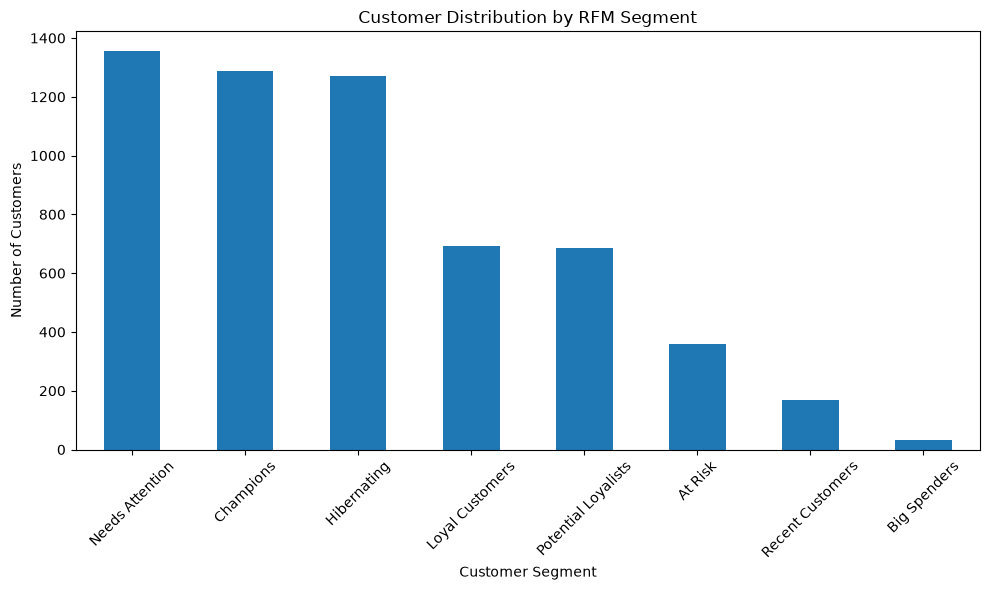

In [17]:
segment_counts = (
    rfm["segment"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

segment_counts.plot(
    kind="bar"
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

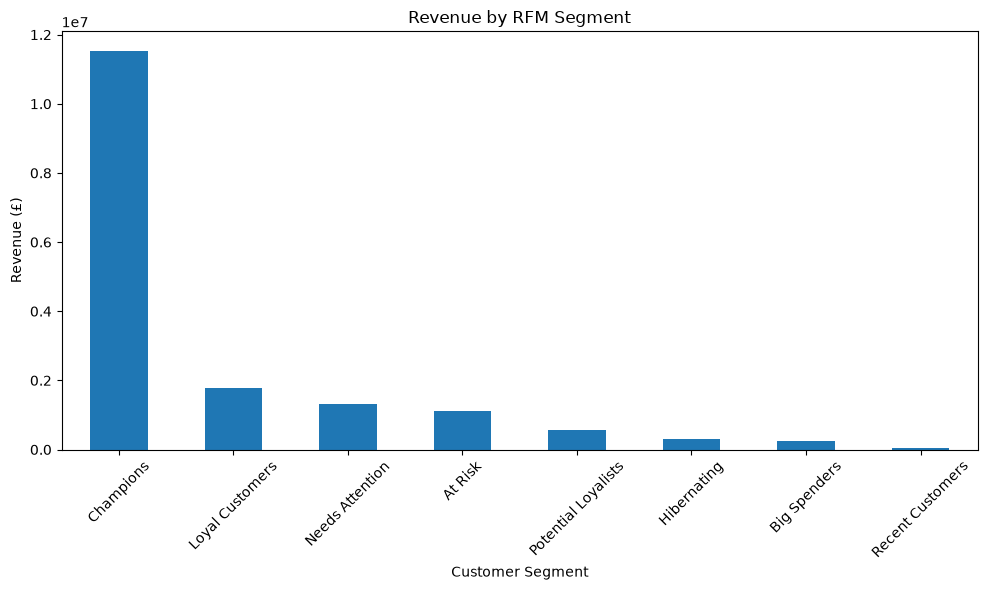

In [18]:
plt.figure(figsize=(10, 6))

segment_analysis.set_index("segment")["revenue"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Revenue by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Interpretation

RFM segmentation reveals meaningful differences in customer behavior and business value.

Champions represent customers who are recently active, frequent purchasers, and high-value contributors. These customers should be protected through loyalty programs, personalized recommendations, exclusive offers, and early access to products.

Loyal Customers demonstrate strong purchasing frequency and should be encouraged to increase their monetary value through cross-selling, upselling, and personalized campaigns.

Potential Loyalists are relatively engaged customers who may develop into stronger long-term customers when supported with targeted recommendations and retention campaigns.

At Risk customers have previously demonstrated meaningful purchasing behavior but show weaker recent activity. These customers are important candidates for win-back campaigns.

Hibernating customers show low recent engagement and lower purchasing activity. The business should use cost-effective reactivation campaigns rather than treating this segment the same as high-value customers.

The next step is to identify the financial contribution of each segment and determine which customer groups should receive the highest retention priority.

# 10. Customer Strategy & Recommendations

The customer analysis provides actionable insights into customer value, purchasing frequency, geographic distribution, and behavioral segments.

The following recommendations translate the analytical findings into practical business strategies.

## Recommended Customer Strategies

### 🏆 Champions
- Protect these high-value customers through loyalty programs.
- Provide exclusive offers and early access to new products.
- Use personalized recommendations to increase lifetime value.

### 💎 Loyal Customers
- Encourage higher spending through cross-selling and upselling.
- Recommend complementary products based on previous purchases.
- Reward continued purchasing behavior.

### 🌱 Potential Loyalists
- Encourage repeat purchases with personalized promotions.
- Recommend products related to previous purchases.
- Introduce loyalty benefits to strengthen long-term engagement.

### ⚠️ At Risk
- Launch targeted win-back campaigns.
- Offer personalized discounts where appropriate.
- Identify previously purchased products for reactivation campaigns.

### 😴 Hibernating
- Use low-cost reactivation campaigns.
- Test targeted promotions before allocating significant marketing budget.
- Avoid treating low-engagement customers the same as high-value customers.

### Other Customers
- Continue monitoring their purchasing behavior.
- Use future transactions to determine whether they move into a more actionable RFM segment.

# 11. Executive Summary

## Key Findings

The customer analysis provides several important insights into the e-commerce business:

1. Customer revenue is concentrated among a smaller group of high-value customers.
2. The business has a substantial repeat-customer base, indicating meaningful customer engagement.
3. Geographic analysis identifies the strongest revenue-generating markets.
4. RFM segmentation reveals distinct groups with different retention and marketing requirements.
5. Champions and Loyal Customers should receive the highest retention priority.
6. At Risk customers represent an important opportunity for win-back campaigns.
7. Hibernating customers should be approached through cost-effective reactivation strategies.
8. Customer-level analysis can support more targeted marketing than treating the entire customer base uniformly.

## Business Impact

These findings can help management improve customer retention, prioritize marketing resources, personalize campaigns, and focus investment on customers with the greatest potential business value.

The analytical outputs will be carried forward into the Power BI dashboard for interactive business reporting.

## 12. Export Customer-Level RFM Dataset

The customer-level RFM dataset combines customer behavior, RFM scores, and customer segments into a single analytical table.

This dataset will be used as the customer-level data source for the Power BI dashboard.

In [19]:
rfm_path = "../data/customer_rfm.csv"

rfm.to_csv(
    rfm_path,
    index=False
)

print("RFM dataset saved successfully.")
print("Customers:", f"{len(rfm):,}")
print("File:", rfm_path)

RFM dataset saved successfully.
Customers: 5,851
File: ../data/customer_rfm.csv
